# CALIPR-style subspace reconstruction for IR T1 mapping — V1 (synthetic phantom)

First version of the **subspace** alternative to the joint locally-low-rank (LLR)
reconstruction in `T1map_3plane_SR_V1.ipynb`, built for the comparison described in
`RECON_COMPARISON.md`. It runs **only on the synthetic phantom** (`synth/phantom.py`).

**Idea (CALIPR: Dvorak et al., Sci Adv 2023, doi:10.1126/sciadv.adh9853).** The signal
evolution of every voxel over the contrast dimension is restricted to a low-dimensional
temporal subspace spanned by the columns of a basis $\Phi$ (here: SVD of simulated IR
curves). Instead of the 4 TI images $x_{TI}(r)$ we reconstruct $K$ coefficient images
$c_k(r)$ with

$$x_{TI}(r) = \sum_{k=1}^{K} \Phi_{TI,k}\, c_k(r), \qquad
\hat c = \arg\min_c \sum_{TI} \| F_{TI} S\, (\Phi c)_{TI} - y_{TI} \|_2^2 + \lambda\, \|\Psi c\|_1 ,$$

with $F_{TI}$ the NUFFT on that TI's sampling pattern, $S$ the coil maps and $\Psi$ a 3D
wavelet applied to each coefficient image. In BART this is `pics -B <basis> -R W:7:0:<lambda>`;
the TI images are recovered with `fmac` (multiply by the basis and sum over the coefficient dim).

**Pipeline in this notebook** (every step shares its inputs with the LLR reference through
`synth/pipeline_utils.py`; only the reconstruction step differs):

| section | step | shared with LLR? |
|---|---|---|
| 3 | load phantom scans, TI/TR from the scan info | yes |
| 4 | temporal basis: dictionary of IR curves -> SVD -> $K$ vectors | CALIPR only |
| 5 | coil maps: `shared_selfcal(..., nmaps=2)` (ENLIVE, coils shared across TI, 2 map sets) | yes |
| 6 | per-TI global phase: estimate from per-TI SENSE, demodulate k-space | CALIPR only |
| 7 | subspace reconstruction per echo group (`pics -B`), expansion (`fmac`) | CALIPR only |
| 8 | map-set combination (`combine_maps`), echo-group average, grid T1 fit | yes |
| 9-10 | evaluation vs truth (`evaluate_t1`), figures, LLR reference for context | yes |

**Scope.** Build + one end-to-end validation on the coronal phantom plane (both echo
groups). The regularisation weight, iteration count and $K$ are **untuned starting values**;
tuning is done later together with the researcher. No parameter sweeps here.

## 1. Environment

In [1]:
import os
import sys
import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

BART_PATH = os.environ.get('BART_TOOLBOX_PATH', '/Users/jackewins/bart/')
os.environ['BART_TOOLBOX_PATH'] = BART_PATH
sys.path.append(os.path.join(BART_PATH, 'python'))
from bart import bart, cfl

REPO_DIR = Path(os.environ.get('QT1_REPO_DIR', Path.cwd()))   # repo root (notebook dir)
sys.path.insert(0, str(REPO_DIR / 'synth'))
import pipeline_utils as pu            # shared loading, coil maps, map combination, fit, evaluation
from phantom import load_scans, LESIONS

%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['figure.dpi'] = 72          # keeps the committed notebook small
ver = bart(0, 'version')                # prints the version string
print('BART toolbox:', BART_PATH)

v1.0.00
BART toolbox: /Users/jackewins/bart


## 2. Configuration

All derived data (coil maps, phase estimates, reconstructions, fits) are cached in
`PROC_DIR`, **outside the repository**; delete a file to force it to be recomputed. The
phantom itself is generated with `python synth/phantom.py <PHANTOM_DIR>`.

The reconstruction parameters below are **untuned starting values**, chosen only to be in
the range the CALIPR reference implementation and the LLR reference use (lambda of order
0.005, 50-80 FISTA iterations). The iteration count matches the LLR reference (80) so
runtimes are comparable.

In [2]:
# ---- data -------------------------------------------------------------------
PHANTOM_DIR = Path(os.environ.get('QT1_PHANTOM_DIR', Path.home() / 'work' / 'phantom'))
PROC_DIR    = PHANTOM_DIR / 'calipr'          # derived data, outside the repo
PLANES      = tuple(os.environ.get('CALIPR_PLANES', 'COR,AX,SAG').split(','))   # COR = validation plane; AX/SAG as a run check
ECHO_GROUPS = (0, 1)                          # both echo groups, averaged after combination

# ---- temporal basis (section 4) --------------------------------------------
DICT_T1_S     = (0.1, 4.0)     # dictionary T1 range (s)
DICT_N        = 1000           # log-spaced dictionary entries
DICT_UNIT_NORM = True          # normalise each curve before the SVD (all T1 weigh equally)
BASIS_K       = 3              # number of basis vectors kept (of 4 TIs)

# ---- coil maps (shared with every method) -----------------------------------
SENS_NMAPS = 2                 # ENLIVE map sets (soft-SENSE), as the LLR reference

# ---- per-TI phase handling (section 6) --------------------------------------
PHASE_MODE    = 'global_demod'                    # 'global_demod' | 'none'
PHASE_EST_CMD = 'pics -S -l2 -r 0.01 -i 20 -U'    # per-TI SENSE used only for the phase estimate

# ---- subspace reconstruction (section 7): UNTUNED ---------------------------
CAL_LAMBDA = 0.005             # l1-wavelet weight on the coefficient images
CAL_ITER   = 80                # FISTA iterations
CAL_CMD    = f'pics -e -S -R W:7:0:{CAL_LAMBDA} -i {CAL_ITER} -U'   # + t=, p=, B= as wrapper kwargs

# ---- diagnostics ------------------------------------------------------------
RUN_PHASE_ABLATION = True      # also reconstruct COR without phase demodulation (design check, not tuning)
LLR_MODE = 'load'              # 'load': llr_<PLANE>.npz from synth/run_llr_reference.py | 'run' | 'off'

REF_TI_IDX = pu.REF_TI_IDX     # TI800 = phase reference
PROC_DIR.mkdir(parents=True, exist_ok=True)
CAL_TAG = (f'K{BASIS_K}{"n" if DICT_UNIT_NORM else "u"}_W{CAL_LAMBDA}_i{CAL_ITER}_'
           f'm{SENS_NMAPS}_{PHASE_MODE}')
print('PHANTOM_DIR', PHANTOM_DIR, '| PROC_DIR', PROC_DIR, '| planes', PLANES)
print('CALIPR:', CAL_CMD, '| tag', CAL_TAG)

PHANTOM_DIR /Users/jackewins/work/phantom | PROC_DIR /Users/jackewins/work/phantom/calipr | planes ('COR', 'AX', 'SAG')
CALIPR: pics -e -S -R W:7:0:0.005 -i 80 -U | tag K3n_W0.005_i80_m2_global_demod


## 3. Phantom scans

`load_scans()` returns, per plane, the four TI scans sorted by the header TI. TI and TR
come from each scan's `info` (as for the real data), never from file names. The phantom
also stores the per-scan global phase offset it applied (`ti_phase_rad`); it is printed
here and used **only** to check the phase estimate in section 6, never in the pipeline.

In [3]:
scans = load_scans(PHANTOM_DIR)
print(f"{'plane':5s} {'TI ms':>7s} {'TR s':>6s} {'matrix':>15s} {'n_PE':>5s} {'R':>5s} {'true phase deg':>15s}")
for p, sl in scans.items():
    for s in sl:
        i = s['info']; nx, ny, nz = i['matrix']
        print(f"{p:5s} {1000 * i['TI_s']:7.2f} {i['TR_s']:6.3f} {str(tuple(i['matrix'])):>15s} "
              f"{i['n_pe']:5d} {ny * nz / i['n_pe']:5.2f} {np.degrees(i['ti_phase_rad']):15.2f}")

TI_s = {p: np.array([s['info']['TI_s'] for s in sl]) for p, sl in scans.items()}
TR_s = {p: np.array([s['info']['TR_s'] for s in sl]) for p, sl in scans.items()}
for p in scans:
    assert np.allclose(TI_s[p], TI_s['COR']) and np.allclose(TR_s[p], TR_s['COR']), \
        'one basis for all planes assumes identical TIs/TRs'
TI_all, TR_all = TI_s['COR'], TR_s['COR']

plane   TI ms   TR s          matrix  n_PE     R  true phase deg
AX      30.75  1.225  (100, 122, 40)   992  4.92           -5.79
AX     150.00  1.350  (100, 122, 40)   800  6.10            1.45
AX     400.00  1.600  (100, 122, 40)   800  6.10            3.90
AX     800.00  2.000  (100, 122, 40)   800  6.10            2.72
COR     30.75  1.225  (112, 100, 44)   736  5.98            3.69
COR    150.00  1.350  (112, 100, 44)   736  5.98            3.57
COR    400.00  1.600  (112, 100, 44)   736  5.98            5.27
COR    800.00  2.000  (112, 100, 44)   736  5.98           -6.06
SAG     30.75  1.225  (122, 112, 36)   672  6.00            6.14
SAG    150.00  1.350  (122, 112, 36)   672  6.00            1.82
SAG    400.00  1.600  (122, 112, 36)   672  6.00           -0.70
SAG    800.00  2.000  (122, 112, 36)   672  6.00           -4.22


## 4. Temporal basis

**Dictionary.** Signed IR curves $S(TI) = 1 - 2e^{-TI/T_1} + e^{-TR/T_1}$ at the protocol's
four (TI, TR) pairs (from the scan info; TR = TI + 1.2 s, except TI31 with TR = 1.225 s),
for `DICT_N` log-spaced $T_1$ in `DICT_T1_S` (100-4000 ms: covers fat/lesions, WM, GM, CSF).
M0 is a free complex scale per voxel, so it is absorbed in the coefficients and not part of
the dictionary.

**Normalisation.** Each curve is normalised to unit $\ell_2$ norm before the SVD
(`DICT_UNIT_NORM`), so every $T_1$ contributes equally to the *shape* the basis must
represent. Without it, long-$T_1$ (CSF) curves, which are the largest in magnitude, dominate
the SVD. Either way, $K = 3$ fits parenchyma equally well (table below); normalised is better
for CSF.

**$K$.** With only 4 TIs the subspace can reduce at most 4 → $K$ unknowns per voxel. The
printed table gives the worst-case relative curve error over the dictionary, and the
$T_1$ error that projection alone causes (noise-free curve → project onto the basis →
`fit_t1_grid`). $K = 3$ is the default (brief): the dimension reduction is small (4 → 3),
so most of the benefit has to come from the spatial wavelet regulariser on the coefficients.

**Basis layout for `pics -B`.** BART expects the basis as a 7-dim array
`(1, 1, 1, 1, 1, TI, K)`: TIs along dim 5 (`TE_DIM`, the same dim that holds the TIs in the
k-space and trajectory) and coefficients along dim 6 (`COEFF_DIM`). `pics -B` then returns
the coefficient images as `(X, Y, Z, 1, maps, 1, K)` and `fmac -s 64` (multiply with the
basis, sum over dim 6 = bit 64) expands them to `(X, Y, Z, 1, maps, TI)`. This was checked
on a small toy problem while building the notebook (pics asserts
`basis_dims[TE_DIM] == ksp_dims[TE_DIM]`, so a transposed basis fails loudly), and is
asserted again on the real output in section 7.

In [4]:
def ir_dictionary(TI, TR, t1_range_s=DICT_T1_S, n=DICT_N, unit_norm=DICT_UNIT_NORM):
    T1 = np.logspace(*np.log10(t1_range_s), n)
    D = np.stack([pu.ir_signal(t, TI, TR) for t in T1])            # (n, TI)
    Dn = D / np.linalg.norm(D, axis=1, keepdims=True) if unit_norm else D
    return T1, D, Dn


def make_basis(Dn, K):
    """SVD of the dictionary; the first K right singular vectors, real, (TI, K)."""
    _, sv, Vh = np.linalg.svd(Dn, full_matrices=False)
    V = Vh[:K].T
    V = V * np.sign(V[np.argmax(np.abs(V), axis=0), np.arange(K)])   # fix SVD sign (cosmetic)
    return V, sv


def to_bart_basis(V):
    """(TI, K) -> BART basis (1, 1, 1, 1, 1, TI, K): TI in dim 5 (TE_DIM), K in dim 6 (COEFF_DIM)."""
    return V.reshape(1, 1, 1, 1, 1, *V.shape).astype(np.complex64)


T1_dict, D_raw, D_fit = ir_dictionary(TI_all, TR_all)
V, sv = make_basis(D_fit, BASIS_K)
BASIS = to_bart_basis(V)
cfl.writecfl(str(PROC_DIR / f'basis_K{BASIS_K}'), BASIS)       # for command-line use

print('singular values (relative):', '  '.join(f'{s / sv[0]:.4f}' for s in sv))
print('\nprojection error of the dictionary curves and the T1 error that projection alone causes')
test_T1 = np.array([0.182, 0.22, 0.26, 0.30, 0.338, 0.38, 1.0, 3.5])   # lesions, WM, GM, CSF
S_test = np.stack([pu.ir_signal(t, TI_all, TR_all) for t in test_T1])
print(f"{'K':>2s} {'worst curve err':>16s} {'at T1 ms':>9s}   T1 bias from projection only (true T1 ms: bias %)")
for K in range(1, len(TI_all) + 1):
    Vk, _ = make_basis(D_fit, K)
    err = np.linalg.norm(D_raw - D_raw @ Vk @ Vk.T, axis=1) / np.linalg.norm(D_raw, axis=1)
    t1p, _, _ = pu.fit_t1_grid(S_test @ Vk @ Vk.T, TI_all, TR_all, np.ones(len(test_T1), bool))
    bias = '  '.join(f'{1000 * a:.0f}:{100 * (b - a) / a:+.1f}' for a, b in zip(test_T1, t1p))
    print(f'{K:2d} {100 * err.max():15.1f}% {1000 * T1_dict[err.argmax()]:9.0f}   {bias}'
          + ('   <- used' if K == BASIS_K else ''))
print('\nbasis (TI x K):\n', np.round(V, 4), '\nBART basis dims:', BASIS.shape)

singular values (relative): 1.0000  0.6484  0.0648  0.0149

projection error of the dictionary curves and the T1 error that projection alone causes
 K  worst curve err  at T1 ms   T1 bias from projection only (true T1 ms: bias %)
 1            91.7%       100   182:+241.4  220:+182.4  260:+139.0  300:+107.1  338:+83.8  380:+63.5  1000:-37.9  3500:-82.2
 2            11.6%       100   182:+1.3  220:+0.2  260:-0.4  300:-0.9  338:-0.7  380:-0.6  1000:+0.7  3500:-10.9
 3             4.3%       100   182:-0.1  220:-0.0  260:+0.1  300:+0.2  338:+0.1  380:-0.0  1000:-0.1  3500:-0.5   <- used
 4             0.0%      1119   182:-0.1  220:-0.0  260:+0.1  300:-0.1  338:+0.1  380:-0.0  1000:-0.1  3500:+0.0

basis (TI x K):
 [[ 0.7888  0.0922  0.6017]
 [ 0.4212  0.4833 -0.5499]
 [-0.0449  0.6728 -0.1474]
 [-0.4455  0.5525  0.5602]] 
BART basis dims: (1, 1, 1, 1, 1, 4, 3)


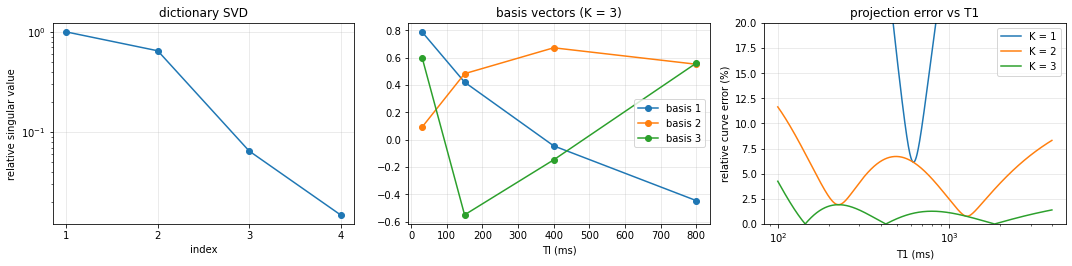

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].semilogy(np.arange(1, len(sv) + 1), sv / sv[0], 'o-')
ax[0].set_xlabel('index'); ax[0].set_ylabel('relative singular value'); ax[0].set_title('dictionary SVD')
ax[0].set_xticks(range(1, len(sv) + 1)); ax[0].grid(alpha=0.3)
for k in range(BASIS_K):
    ax[1].plot(1000 * TI_all, V[:, k], 'o-', label=f'basis {k + 1}')
ax[1].set_xlabel('TI (ms)'); ax[1].set_title(f'basis vectors (K = {BASIS_K})'); ax[1].legend(); ax[1].grid(alpha=0.3)
for K in range(1, len(TI_all)):
    Vk, _ = make_basis(D_fit, K)
    err = np.linalg.norm(D_raw - D_raw @ Vk @ Vk.T, axis=1) / np.linalg.norm(D_raw, axis=1)
    ax[2].semilogx(1000 * T1_dict, 100 * err, label=f'K = {K}')
ax[2].set_xlabel('T1 (ms)'); ax[2].set_ylabel('relative curve error (%)'); ax[2].set_ylim(0, 20)
ax[2].set_title('projection error vs T1'); ax[2].legend(); ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Coil maps (shared with the LLR reference)

`pu.shared_selfcal(scans_plane, e, nmaps=2)`: ENLIVE (`ncalib`) on all four TIs of one
plane and echo group, with **one set of coils shared across TI** and two map sets
(soft-SENSE). Maps are `(X, Y, Z, coil, maps)`. Identical call and inputs to the LLR
reference, so any difference downstream is the reconstruction's.

With two map sets, `pics` reconstructs one image per map set; with `-B` it reconstructs
$K$ coefficient images **per map set**, i.e. `2K` complex unknowns per voxel. Each map set
is expanded separately and then combined with the same phase-referenced combination as LLR
(section 8).

In [6]:
def get_sens(p, e):
    f = PROC_DIR / f'sens_{p}_e{e}_m{SENS_NMAPS}.npz'
    if f.exists():
        z = np.load(f); return z['s'], float(z['seconds']), 'cached'
    t0 = time.time()
    s = pu.shared_selfcal(scans[p], e, nmaps=SENS_NMAPS)
    dt = time.time() - t0
    np.savez(f, s=s, seconds=dt)
    return s, dt, 'computed'


sens, runtime = {}, {}
for p in PLANES:
    for e in ECHO_GROUPS:
        sens[p, e], dt, state = get_sens(p, e)
        runtime[p, e, 'coil maps'] = dt
        print(f'{p} echo {e}: maps {sens[p, e].shape}  {dt:5.0f} s  [{state}]')

COR echo 0: maps (112, 100, 44, 8, 2)     84 s  [cached]
COR echo 1: maps (112, 100, 44, 8, 2)     82 s  [cached]
AX echo 0: maps (100, 122, 40, 8, 2)     85 s  [cached]
AX echo 1: maps (100, 122, 40, 8, 2)     77 s  [cached]
SAG echo 0: maps (122, 112, 36, 8, 2)     67 s  [cached]
SAG echo 1: maps (122, 112, 36, 8, 2)     72 s  [cached]


## 6. Per-TI phase offsets

**Why it matters for a subspace model.** The basis is real. With complex coefficients, a
voxel's modelled series is $x_{TI} = (\Phi a)_{TI} + i\,(\Phi b)_{TI}$: real and imaginary
parts each lie in the real subspace. A phase that is **common to all TIs** (coil/background
phase, the extra phase of echo group 1) is therefore represented exactly. A phase that
**differs between TIs** is not: each TI is a separate scan, and a global phase offset
$\delta\phi_{TI}$ (SD ≈ 5°, as measured between TI scans on real data; applied by the phantom)
turns $x_{TI} = e^{i\phi(r)} s_{TI}(r)$ into $e^{i(\phi(r) + \delta\phi_{TI})} s_{TI}(r)$, whose
component outside the subspace ($\approx \delta\phi_{TI} s_{TI}$ in quadrature) cannot be
fitted and ends up as model error. (For LLR this is irrelevant: the per-TI phase does not
change the rank, and `combine_maps` references everything to TI800.)

**What V1 does (`PHASE_MODE = 'global_demod'`).**

1. Reconstruct each TI **independently** with a quick, lightly regularised SENSE
   (`PHASE_EST_CMD`, 20 CG iterations, same coil maps). No coupling across TI, so no model
   assumption about the TI dependence enters the estimate.
2. For each TI form $z(r) = x_{TI}(r)\,x^*_{800}(r)$ per voxel and map set. Its phase is
   $\delta\phi_{TI} - \delta\phi_{800}$ **plus 0 or π** depending on the (tissue-dependent)
   sign of $s_{TI}s_{800}$. Squaring removes the sign: $\widehat{\Delta\phi}_{TI} =
   \tfrac12 \arg \sum_r z^2/|z|$ (magnitude-weighted). This is unambiguous for
   $|\Delta\phi| < 90°$; measured offsets are 4-9°.
3. Multiply that TI's k-space by $e^{-i\widehat{\Delta\phi}_{TI}}$ before the subspace
   reconstruction. Because the offset is a scalar per TI, this is exactly equivalent to
   putting $e^{i\Delta\phi_{TI}}$ into a **complex basis** $\Phi'_{TI,k} = e^{i\Delta\phi_{TI}}\Phi_{TI,k}$
   (same least-squares problem), but it keeps the basis real and the expanded images in the
   TI800 phase frame.

Estimated offsets are compared with the phantom's true offsets (relative to TI800) below —
this uses the truth only as a check.

**Alternatives not implemented (for discussion):**

* **Data-driven complex basis**, as in the CALIPR T2 reference code: SVD of a preliminary
  reconstruction's TI series (complex). Captures phase offsets implicitly, but a 4-TI
  complex basis with K = 3 may keep the offsets and discard T1 information instead, and the
  basis then depends on the preliminary reconstruction (its regularisation, aliasing).
* **Joint/iterative estimation**: alternate subspace reconstruction and re-estimation of
  $\Delta\phi_{TI}$ from the data residual (or put the phase into the forward model).
  Would remove the dependence on the quick per-TI SENSE, which is noisy at the
  near-null TI.
* **Spatially varying per-TI phase** (e.g. B0 drift or motion between TI scans): a global
  scalar cannot capture it. A low-resolution phase map per TI could be demodulated in image
  space by folding it into per-TI coil maps (maps would then differ per TI).
* **Real-valued coefficients** (`pics -c`): after removing both the TI-common phase
  (fold $e^{i\phi(r)}$ from a TI800 reconstruction into the coil maps) and the per-TI
  offsets, the coefficients are real, which halves the unknowns (8 real → 3 real per voxel
  instead of 8 → 6). This is where a 4-TI subspace could gain most, but it relies on an
  accurate phase map and on the soft-SENSE map sets carrying a consistent phase.
* `PHASE_MODE = 'none'`: ignore the offsets (used below as an ablation on COR only, to show
  whether the handling matters at all at SD 5°).

In [7]:
def estimate_ti_phase(p, e):
    """Global phase of each TI relative to the reference TI (rad), from per-TI SENSE images."""
    f = PROC_DIR / f'tiphase_{p}_e{e}_m{SENS_NMAPS}.npz'
    if f.exists():
        z = np.load(f); return z['dphi'], float(z['seconds']), 'cached'
    t0 = time.time()
    xs = []
    for s in scans[p]:
        t, d = pu.load_echo(s['stem'], e)
        x = pu.checked(bart(1, PHASE_EST_CMD, d, sens[p, e], t=t))
        xs.append(x if x.ndim == 4 else x[..., None])                 # (X, Y, Z, map set)
    x = np.stack(xs, axis=-1)                                          # (X, Y, Z, M, TI)
    z = x * np.conj(x[..., REF_TI_IDX])[..., None]                     # sign(s_TI s_ref) e^{i dphi}
    w = np.sum(z ** 2 / np.maximum(np.abs(z), 1e-30), axis=(0, 1, 2, 3))
    dphi = (0.5 * np.angle(w)).astype(np.float64)                      # sign ambiguity removed
    dt = time.time() - t0
    np.savez(f, dphi=dphi, seconds=dt)
    return dphi, dt, 'computed'


dphi = {}
for p in PLANES:
    true = np.array([s['info']['ti_phase_rad'] for s in scans[p]])
    true = np.degrees(true - true[REF_TI_IDX])
    for e in ECHO_GROUPS:
        if PHASE_MODE == 'global_demod':
            dphi[p, e], dt, state = estimate_ti_phase(p, e)
        else:
            dphi[p, e], dt, state = np.zeros(len(scans[p])), 0.0, 'off'
        runtime[p, e, 'phase estimate'] = dt
        print(f'{p} echo {e} [{state}, {dt:.0f} s]  TI (ms): ' +
              '  '.join(f'{1000 * t:5.0f}' for t in TI_s[p]))
        print(f'   estimated rel. phase (deg): ' + '  '.join(f'{v:5.1f}' for v in np.degrees(dphi[p, e])))
        print(f'   true rel. phase (deg):      ' + '  '.join(f'{v:5.1f}' for v in true))

COR echo 0 [cached, 23 s]  TI (ms):    31    150    400    800
   estimated rel. phase (deg):   9.8    6.4   11.3    0.0
   true rel. phase (deg):        9.7    9.6   11.3    0.0
COR echo 1 [cached, 14 s]  TI (ms):    31    150    400    800
   estimated rel. phase (deg):   9.7    6.3   11.4   -0.0
   true rel. phase (deg):        9.7    9.6   11.3    0.0
AX echo 0 [cached, 37 s]  TI (ms):    31    150    400    800
   estimated rel. phase (deg):  -9.8   -1.7    1.3   -0.0
   true rel. phase (deg):       -8.5   -1.3    1.2    0.0
AX echo 1 [cached, 37 s]  TI (ms):    31    150    400    800
   estimated rel. phase (deg):  -9.9   -1.7    1.3    0.0
   true rel. phase (deg):       -8.5   -1.3    1.2    0.0
SAG echo 0 [cached, 68 s]  TI (ms):    31    150    400    800
   estimated rel. phase (deg):  10.4    7.2    3.6   -0.0
   true rel. phase (deg):       10.4    6.0    3.5    0.0
SAG echo 1 [cached, 69 s]  TI (ms):    31    150    400    800
   estimated rel. phase (deg):  10.4    6.8 

## 7. Subspace reconstruction per echo group

For each plane and echo group: `stack_tis` (TIs in dim 5, zero-weight pattern `P` if the PE
counts differ, as for axial), per-TI demodulation, then

`pics -e -S -R W:7:0:<lambda> -i <iter> -U` with `t=T, p=P, B=BASIS` passed as **wrapper
keyword arguments** (the wrapper writes `-t <file> -p <file> -B <file>`; the command string
never ends in a bare flag).

* `-R W:7:0:lambda`: l1-wavelet over the three spatial dims (bitmask 7), no joint dims —
  each coefficient image (and each map set) is regularised separately with the same lambda.
  The coefficients are ordered by energy, so a single lambda penalises the small, T1-carrying
  higher coefficients relatively more than $c_1$. This is how the CALIPR reference does it; a
  per-coefficient weighting or joint sparsity across coefficients (`W:7:64:lambda`) are
  options for the tuning stage.
* `-e -S -U`: eigenvalue-based step size, rescaling of the output, low-memory NUFFT — as
  in the LLR reference. FISTA (pics default for l1).
* Output `(X, Y, Z, 1, maps, 1, K)`; `fmac -s 64` with the basis gives `(X, Y, Z, 1, maps, TI)`.

Results (coefficients and expanded TI images) are cached per plane / echo / settings.

In [8]:
def calipr_recon(p, e, dphi_e, cmd=CAL_CMD, basis=BASIS, tag=CAL_TAG):
    """Subspace reconstruction of one plane / echo group.
    Returns coefficients (X,Y,Z,M,K), TI images (X,Y,Z,M,TI), seconds, state."""
    f = PROC_DIR / f'calipr_{p}_e{e}_{tag}.npz'
    if f.exists():
        z = np.load(f); return z['coef'], z['img'], float(z['seconds']), 'cached'
    t0 = time.time()
    T, D, P = pu.stack_tis(scans[p], e)
    D = (D * np.exp(-1j * dphi_e).reshape((1,) * 5 + (-1,))).astype(np.complex64)   # demodulate per TI
    kw = {'t': T, 'B': basis} if P is None else {'t': T, 'p': P, 'B': basis}
    c = bart(1, cmd, D, sens[p, e], **kw)
    if c is None or np.ndim(c) < 3:
        raise RuntimeError('pics -B failed - see the error printed above')
    c = c.reshape(c.shape + (1,) * (7 - c.ndim))                       # (X,Y,Z,1,M,1,K)
    assert c.shape[5] == 1 and c.shape[6] == basis.shape[6], c.shape
    x = bart(1, 'fmac -s 64', c, basis)                                # sum over dim 6 -> TI in dim 5
    x = x.reshape(x.shape + (1,) * (6 - x.ndim))                       # (X,Y,Z,1,M,TI)
    assert x.shape[5] == basis.shape[5], x.shape
    coef = c[:, :, :, 0, :, 0, :].astype(np.complex64)                 # (X,Y,Z,M,K)
    img = x[:, :, :, 0, :, :].astype(np.complex64)                     # (X,Y,Z,M,TI)
    dt = time.time() - t0
    np.savez(f, coef=coef, img=img, seconds=dt)
    return coef, img, dt, 'reconstructed'


coef, img = {}, {}
for p in PLANES:
    for e in ECHO_GROUPS:
        coef[p, e], img[p, e], dt, state = calipr_recon(p, e, dphi[p, e])
        runtime[p, e, 'subspace recon'] = dt
        print(f'{p} echo {e}: coef {coef[p, e].shape}  TI images {img[p, e].shape}  {dt:6.0f} s  [{state}]')

COR echo 0: coef (112, 100, 44, 2, 3)  TI images (112, 100, 44, 2, 4)      63 s  [cached]
COR echo 1: coef (112, 100, 44, 2, 3)  TI images (112, 100, 44, 2, 4)      59 s  [cached]
AX echo 0: coef (100, 122, 40, 2, 3)  TI images (100, 122, 40, 2, 4)     137 s  [cached]
AX echo 1: coef (100, 122, 40, 2, 3)  TI images (100, 122, 40, 2, 4)     137 s  [cached]
SAG echo 0: coef (122, 112, 36, 2, 3)  TI images (122, 112, 36, 2, 4)     104 s  [cached]


SAG echo 1: coef (122, 112, 36, 2, 3)  TI images (122, 112, 36, 2, 4)     100 s  [cached]


## 8. Map-set combination, echo-group average, T1 fit

Identical to the LLR reference (`synth/run_llr_reference.py`):

* `combine_maps`: each map set phase-referenced to its own TI800 image and summed → one
  complex image per TI whose **real part** is the signed (PSIR) signal.
* The signed signals of the two echo groups are averaged.
* `fit_t1_grid`: closed-form M0, dense log-spaced T1 grid (20 ms-5 s), inside the truth
  mask `label >= 3` (CSF, GM, WM, lesions; same mask as the LLR script). Returns T1, M0, R².

Known limitation (brief): CSF is still inverted at TI800, so PSIR flips its polarity and
the fit returns a short T1. Not a reconstruction issue; reported but not addressed.

In [9]:
truth = {p: dict(np.load(PHANTOM_DIR / f'truth_{p}.npz')) for p in PLANES}
signed, T1, M0, R2 = {}, {}, {}, {}
for p in PLANES:
    t0 = time.time()
    S = np.mean([np.real(pu.combine_maps(img[p, e])) for e in ECHO_GROUPS], axis=0)   # (X,Y,Z,TI)
    signed[p] = S
    T1[p], M0[p], R2[p] = pu.fit_t1_grid(S, TI_s[p], TR_s[p], truth[p]['label'] >= 3)
    runtime[p, None, 'combine + fit'] = time.time() - t0
    np.savez_compressed(PROC_DIR / f'fit_{p}_{CAL_TAG}.npz', signed=S.astype(np.float32),
                        T1_s=T1[p], M0=M0[p], R2=R2[p])
    print(f'{p}: fit done ({runtime[p, None, "combine + fit"]:.0f} s), '
          f'median R2 in brain {np.nanmedian(R2[p][truth[p]["label"] >= 4]):.4f}')

COR: fit done (2 s), median R2 in brain 0.9992


AX: fit done (1 s), median R2 in brain 0.9966


SAG: fit done (1 s), median R2 in brain 0.9976


## 9. Evaluation against the truth

`evaluate_t1` / `print_eval`: tissue masks are eroded truth labels; each lesion uses the
voxels holding ≥ half its peak partial-volume fraction. **`ideal`** is the T1 fitted to the
fully sampled, noise-free, resolution-limited signal (partial volume only), so **bias vs
ideal is the reconstruction's own error** — the number to compare methods on.

The LLR reference (for context only, no tuning of either) is loaded from
`<PHANTOM_DIR>/llr_<PLANE>.npz`, written by `python synth/run_llr_reference.py <dir> <PLANE>`
(same coil-map call, same combination and fit). `LLR_MODE = 'run'` computes it here instead.

In [10]:
def get_llr(p):
    f = PHANTOM_DIR / f'llr_{p}.npz'
    if LLR_MODE == 'off':
        return None
    if f.exists():
        return dict(np.load(f))
    if LLR_MODE != 'run':
        print(f'{f.name} not found - run synth/run_llr_reference.py or set LLR_MODE = "run"')
        return None
    sig = []
    for e in ECHO_GROUPS:
        x = pu.llr_recon(scans[p], sens[p, e], e)
        sig.append(np.real(pu.combine_maps(x)))
    S = 0.5 * (sig[0] + sig[1])
    t1, m0, r2 = pu.fit_t1_grid(S, TI_s[p], TR_s[p], truth[p]['label'] >= 3)
    np.savez_compressed(f, signed=S.astype(np.float32), T1_s=t1, M0=m0, R2=r2)
    return dict(signed=S, T1_s=t1, M0=m0, R2=r2)


rows, llr, rows_llr = {}, {}, {}
for p in PLANES:
    rows[p] = pu.evaluate_t1(T1[p], truth[p])
    pu.print_eval(rows[p], f'\n{p}: CALIPR subspace ({CAL_CMD}, K={BASIS_K}, {PHASE_MODE})')
    llr[p] = get_llr(p)
    if llr[p] is not None:
        rows_llr[p] = pu.evaluate_t1(llr[p]['T1_s'], truth[p])
        pu.print_eval(rows_llr[p], f'\n{p}: LLR reference ({pu.LLR_CMD}) - context only')


COR: CALIPR subspace (pics -e -S -R W:7:0:0.005 -i 80 -U, K=3, global_demod)
true = phantom T1; ideal = fit to fully sampled, noise-free, resolution-limited signal (partial volume only); bias vs ideal = reconstruction alone
region                 n    true   ideal     est     sd  bias% vs ideal% peak PV
WM                 70965   259.8   259.8   254.7   29.0   -2.0      -2.0 
GM                  3750   309.2   308.8   302.5   37.3   -2.2      -2.0 
CSF                  394  3543.3  3862.6   223.5  132.6  -93.7     -94.2 
lesion 1 (10 mm)      34   338.0   313.7   304.3   20.8  -10.0      -3.0    1.00
lesion 2 (6 mm)       10   338.0   304.2   229.5   13.0  -32.1     -24.6    0.75
lesion 3 (4 mm)        4   338.0   293.1   276.2    3.3  -18.3      -5.7    0.50
lesion 4 (2 mm)        1   338.0   268.3   303.8    0.0  -10.1      13.2    0.19
lesion 5 (10 mm)      34   182.0   203.9   227.8   17.3   25.2      11.7    1.00
lesion 6 (6 mm)        7   182.0   211.5   230.0    9.9   26.4     

COR: T1 (ms), bias vs ideal (%)
region                 n    true   ideal   CALIPR     sd  vs ideal      LLR     sd  vs ideal
WM                 70965   259.8   259.8    254.7   29.0     -2.0%    258.6   20.2     -0.4%
GM                  3750   309.2   308.8    302.5   37.3     -2.0%    307.1   30.9     -0.5%
CSF                  394  3543.3  3862.6    223.5  132.6    -94.2%    190.3  270.5    -95.1%
lesion 1 (10 mm)      34   338.0   313.7    304.3   20.8     -3.0%    293.5   31.2     -6.4%
lesion 2 (6 mm)       10   338.0   304.2    229.5   13.0    -24.6%    278.6    5.4     -8.4%
lesion 3 (4 mm)        4   338.0   293.1    276.2    3.3     -5.7%    275.6    3.3     -5.9%
lesion 4 (2 mm)        1   338.0   268.3    303.8    0.0    +13.2%    289.1    0.0     +7.7%
lesion 5 (10 mm)      34   182.0   203.9    227.8   17.3    +11.7%    230.2   15.4    +12.9%
lesion 6 (6 mm)        7   182.0   211.5    230.0    9.9     +8.7%    231.3    7.8     +9.4%
lesion 7 (4 mm)        4   182.0   225

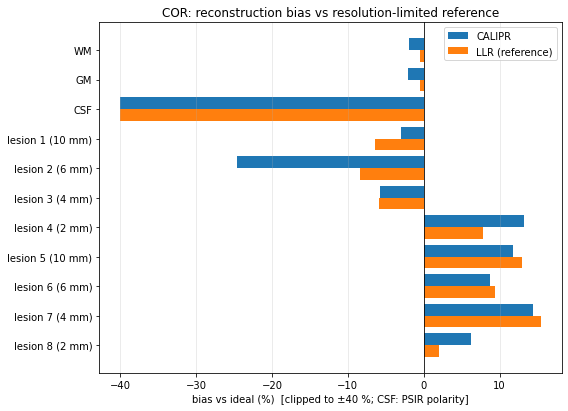

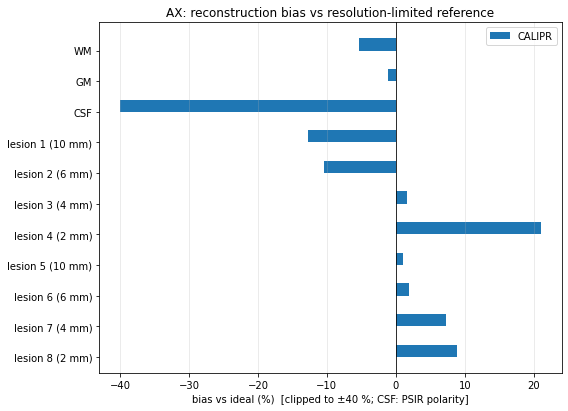

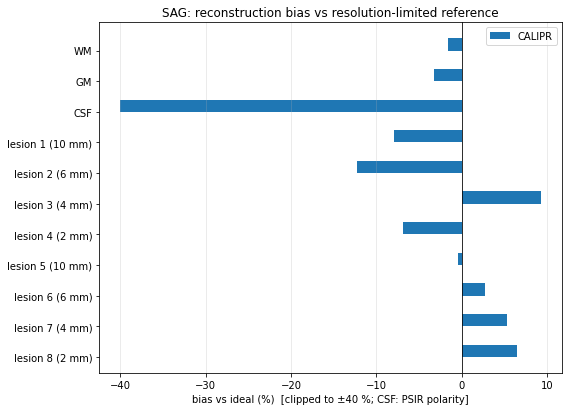

In [11]:
def side_by_side(p):
    """Compact table: bias vs ideal for CALIPR and (if available) LLR."""
    hdr = f"{'region':18s} {'n':>5s} {'true':>7s} {'ideal':>7s} {'CALIPR':>8s} {'sd':>6s} {'vs ideal':>9s}"
    if p in rows_llr:
        hdr += f" {'LLR':>8s} {'sd':>6s} {'vs ideal':>9s}"
    print(f'{p}: T1 (ms), bias vs ideal (%)\n' + hdr)
    for i, r in enumerate(rows[p]):
        line = (f"{r['region']:18s} {r['n']:5d} {r['true_ms']:7.1f} {r.get('ideal_ms', np.nan):7.1f} "
                f"{r['est_ms']:8.1f} {r['sd_ms']:6.1f} {r.get('bias_vs_ideal_pct', np.nan):+8.1f}%")
        if p in rows_llr:
            q = rows_llr[p][i]
            line += f" {q['est_ms']:8.1f} {q['sd_ms']:6.1f} {q.get('bias_vs_ideal_pct', np.nan):+8.1f}%"
        print(line)


for p in PLANES:
    side_by_side(p); print()

# bar chart of bias vs ideal
for p in PLANES:
    names = [r['region'] for r in rows[p]]
    y = np.arange(len(names))
    fig, ax = plt.subplots(figsize=(8, 0.42 * len(names) + 1.2))
    b1 = [r.get('bias_vs_ideal_pct', np.nan) for r in rows[p]]
    ax.barh(y - 0.2, np.clip(b1, -40, 40), 0.4, label='CALIPR', color='#1f77b4')
    if p in rows_llr:
        b2 = [r.get('bias_vs_ideal_pct', np.nan) for r in rows_llr[p]]
        ax.barh(y + 0.2, np.clip(b2, -40, 40), 0.4, label='LLR (reference)', color='#ff7f0e')
    ax.set_yticks(y); ax.set_yticklabels(names); ax.invert_yaxis()
    ax.axvline(0, color='k', lw=0.8); ax.set_xlabel('bias vs ideal (%)  [clipped to ±40 %; CSF: PSIR polarity]')
    ax.set_title(f'{p}: reconstruction bias vs resolution-limited reference'); ax.grid(alpha=0.3, axis='x')
    ax.legend(); plt.tight_layout(); plt.show()

## 10. Figures

Slices are chosen through the largest lesions (lesion 1, long T1, and lesion 5, short T1,
share one position along the slice axis in every plane), since the mid slice contains no
lesion. In-plane aspect ratio from the voxel size.

1. **Coefficient images** (echo group 0): top row map set 0, $c_k$ phase-referenced to $c_1$
   (real part, signed): $c_1$ ≈ M0-weighted mean curve, $c_2$ and $c_3$ carry the T1
   contrast. Bottom row: magnitude of map set 1's coefficients (the soft-SENSE second set).
2. **TI images**: magnitude (RSS over map sets, echo group 0) and the signed, combined,
   echo-averaged signal that is fitted.
3. **T1 map vs truth vs error**, R² of the fit, and the LLR reference for context.

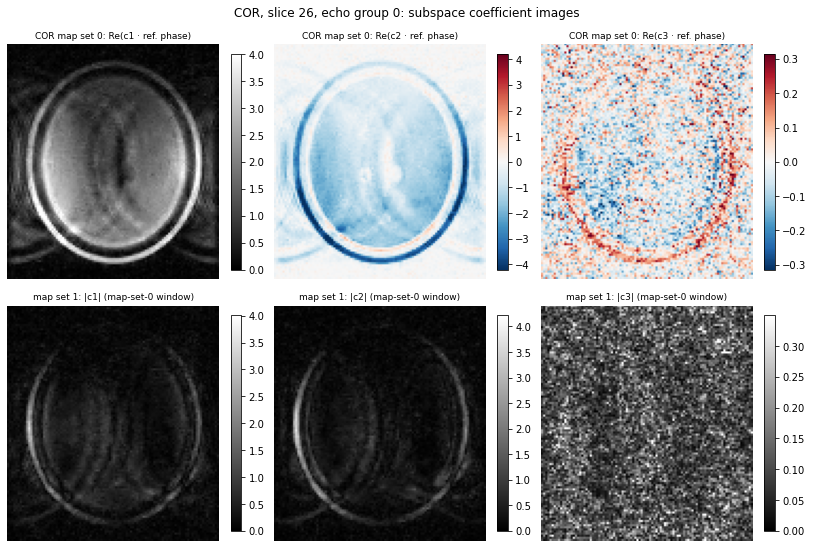

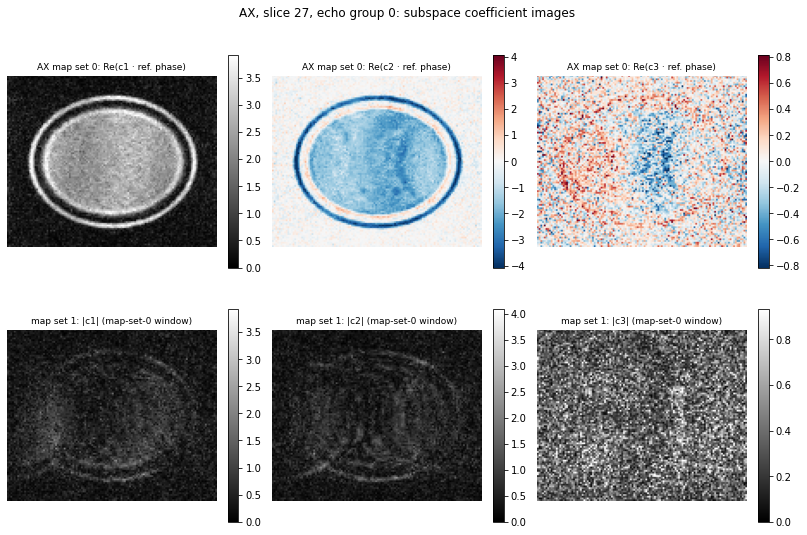

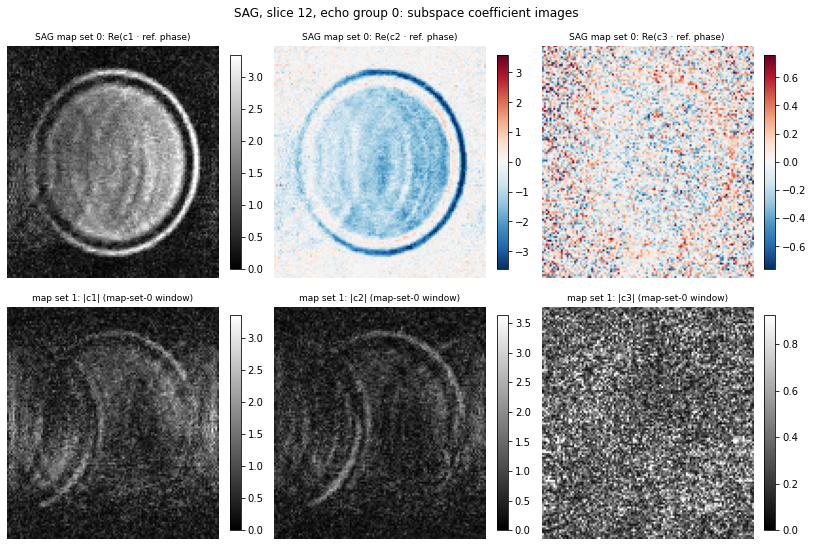

In [12]:
def lesion_slice(p):
    fr = truth[p]['lesion_frac_by_id'][0]                  # lesion 1 (10 mm, long T1)
    return int(np.argmax(fr.sum(axis=(0, 1))))


def aspect(p):
    sp_ = pu.spacing_of(scans[p][REF_TI_IDX]['info'])
    return sp_[0] / sp_[1]


for p in PLANES:
    z = lesion_slice(p); asp = aspect(p)
    c0 = coef[p, 0]                                        # (X,Y,Z,M,K)
    K, M = c0.shape[-1], c0.shape[3]
    ref = c0[:, :, z, 0, 0]
    rphase = np.conj(ref) / np.maximum(np.abs(ref), 1e-12 * np.abs(ref).max())
    fig, axes = plt.subplots(M, K, figsize=(3.8 * K, 3.9 * M), squeeze=False)
    for k in range(K):
        v = np.real(c0[:, :, z, 0, k] * rphase)
        lim = np.percentile(np.abs(v), 99.5)
        im = axes[0, k].imshow(v, cmap='RdBu_r' if k else 'gray', vmin=-lim if k else 0, vmax=lim, aspect=asp)
        axes[0, k].set_title(f'{p} map set 0: Re(c{k + 1} · ref. phase)', fontsize=9)
        plt.colorbar(im, ax=axes[0, k], fraction=0.046)
        for m in range(1, M):
            v = np.abs(c0[:, :, z, m, k]); vmax = np.percentile(np.abs(c0[:, :, z, 0, k]), 99.5)
            im = axes[m, k].imshow(v, cmap='gray', vmin=0, vmax=vmax, aspect=asp)
            axes[m, k].set_title(f'map set {m}: |c{k + 1}| (map-set-0 window)', fontsize=9)
            plt.colorbar(im, ax=axes[m, k], fraction=0.046)
    for a in axes.ravel():
        a.axis('off')
    plt.suptitle(f'{p}, slice {z}, echo group 0: subspace coefficient images'); plt.tight_layout(); plt.show()

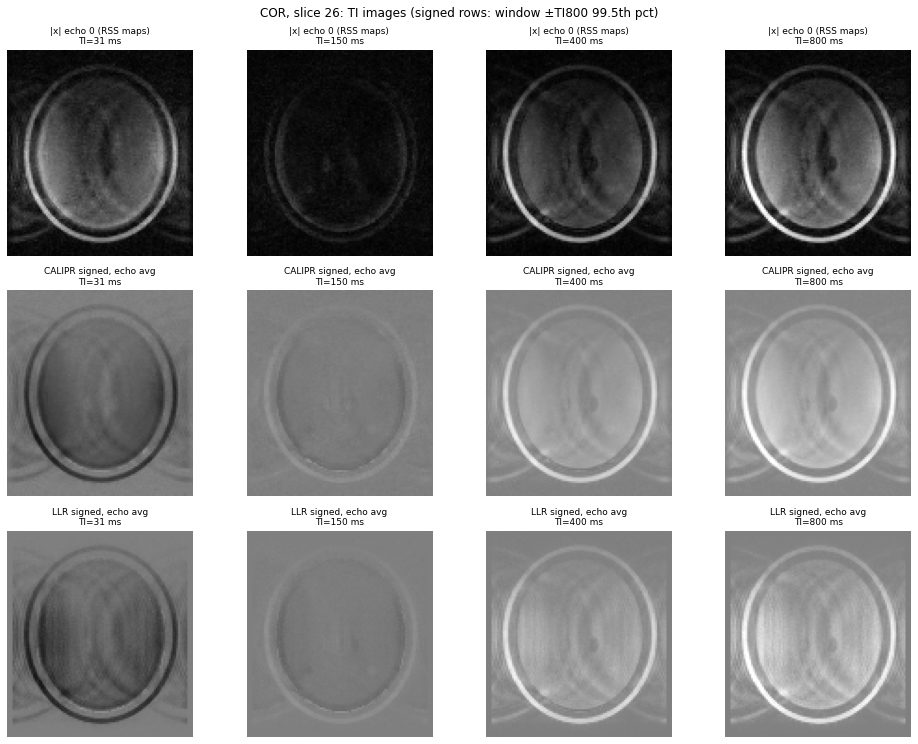

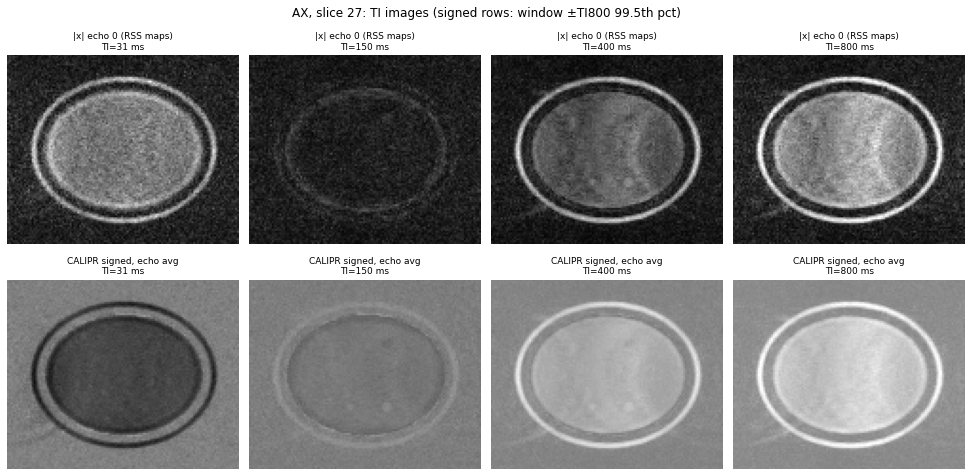

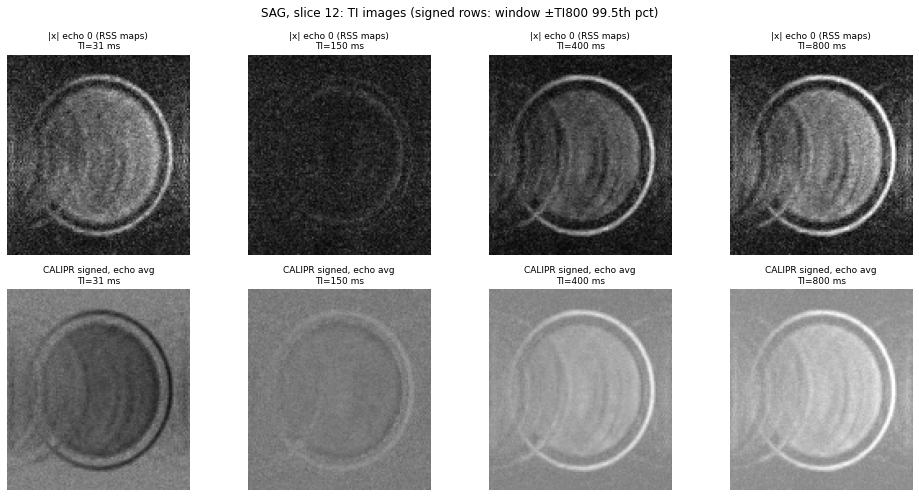

In [13]:
for p in PLANES:
    z = lesion_slice(p); asp = aspect(p); n = len(TI_s[p])
    mag = pu.rss_maps(img[p, 0])
    rows_ = [('|x| echo 0 (RSS maps)', mag, False), ('CALIPR signed, echo avg', signed[p], True)]
    if llr.get(p) is not None:
        rows_.append(('LLR signed, echo avg', llr[p]['signed'], True))
    fig, axes = plt.subplots(len(rows_), n, figsize=(3.4 * n, 3.5 * len(rows_)), squeeze=False)
    for r, (name, v, sgn) in enumerate(rows_):
        vmax = np.percentile(np.abs(v[:, :, z, REF_TI_IDX]), 99.5)
        for c in range(n):
            axes[r, c].imshow(v[:, :, z, c], cmap='gray', vmin=-vmax if sgn else 0, vmax=vmax, aspect=asp)
            axes[r, c].set_title(f'{name}\nTI={1000 * TI_s[p][c]:.0f} ms', fontsize=9); axes[r, c].axis('off')
    plt.suptitle(f'{p}, slice {z}: TI images (signed rows: window ±TI800 99.5th pct)'); plt.tight_layout(); plt.show()

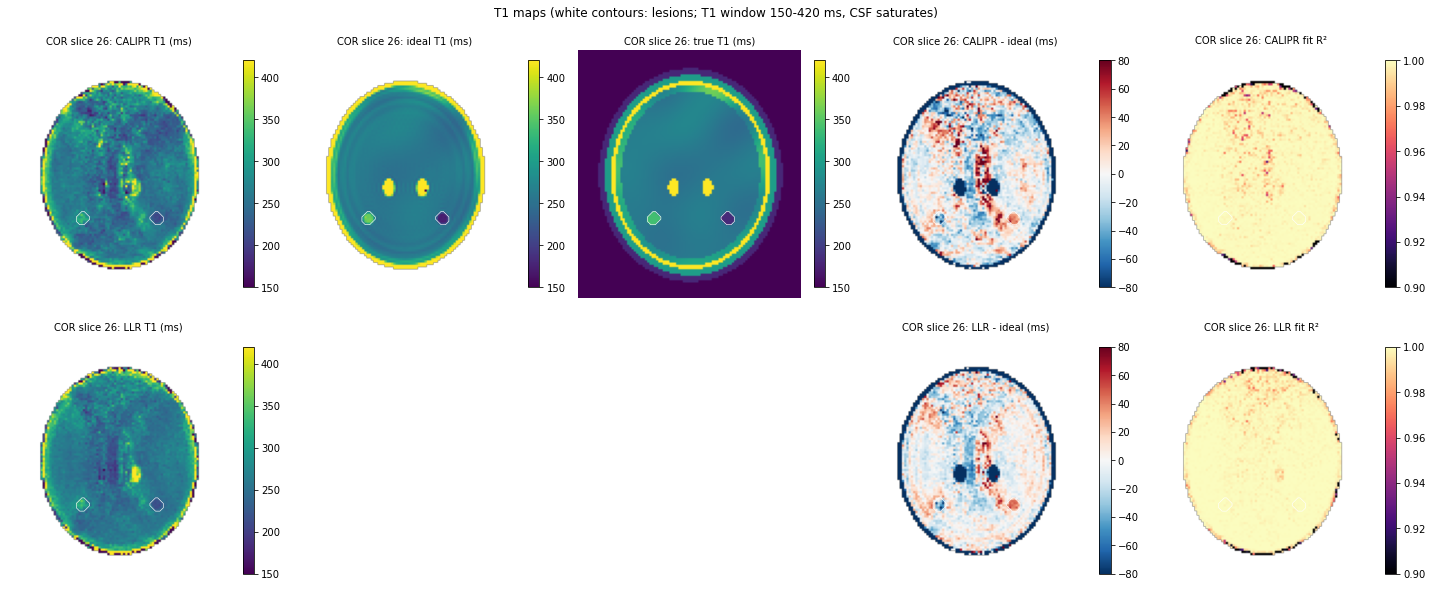

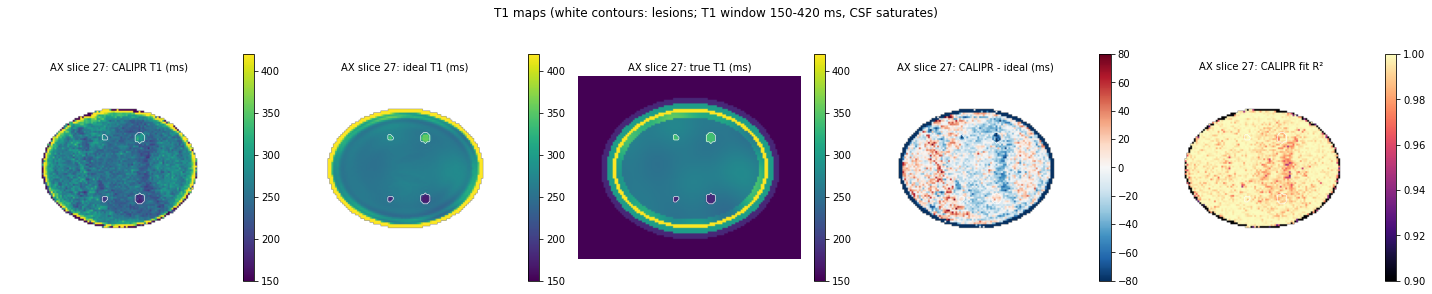

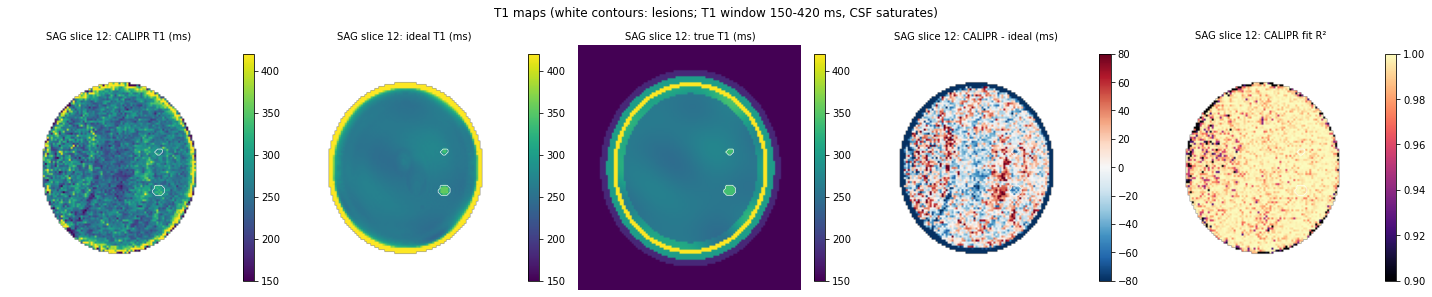

In [14]:
for p in PLANES:
    z = lesion_slice(p); asp = aspect(p)
    ideal = truth[p]['T1_ideal_ms'][:, :, z]
    t1c = 1000 * T1[p][:, :, z]
    panels = [(t1c, 'CALIPR T1 (ms)', 'viridis', 150, 420), (ideal, 'ideal T1 (ms)', 'viridis', 150, 420),
              (truth[p]['T1_ms'][:, :, z], 'true T1 (ms)', 'viridis', 150, 420),
              (t1c - ideal, 'CALIPR - ideal (ms)', 'RdBu_r', -80, 80), (R2[p][:, :, z], 'CALIPR fit R²', 'magma', 0.9, 1.0)]
    if llr.get(p) is not None:
        t1l = 1000 * llr[p]['T1_s'][:, :, z]
        panels += [(t1l, 'LLR T1 (ms)', 'viridis', 150, 420), None, None,
                   (t1l - ideal, 'LLR - ideal (ms)', 'RdBu_r', -80, 80), (llr[p]['R2'][:, :, z], 'LLR fit R²', 'magma', 0.9, 1.0)]
    nr = len(panels) // 5
    fig, axes = plt.subplots(nr, 5, figsize=(20, 4.3 * nr), squeeze=False)
    for a, pan in zip(axes.ravel(), panels):
        a.axis('off')
        if pan is None:
            continue
        v, ttl, cm, lo, hi = pan
        im = a.imshow(v, cmap=cm, vmin=lo, vmax=hi, aspect=asp)
        a.contour(truth[p]['lesion_id'][:, :, z] > 0, [0.5], colors='w', linewidths=0.6)
        a.set_title(f'{p} slice {z}: {ttl}', fontsize=10); plt.colorbar(im, ax=a, fraction=0.046)
    plt.suptitle('T1 maps (white contours: lesions; T1 window 150-420 ms, CSF saturates)')
    plt.tight_layout(); plt.show()

**Per-lesion zoom.** Each lesion at the slice of its peak partial-volume fraction,
±12 voxels around it: ideal, CALIPR, LLR (if available), CALIPR − ideal. Needed because the
lesions lie on different slices, and a local artefact near one lesion (aliasing streak,
wavelet ringing) dominates that lesion's mean.

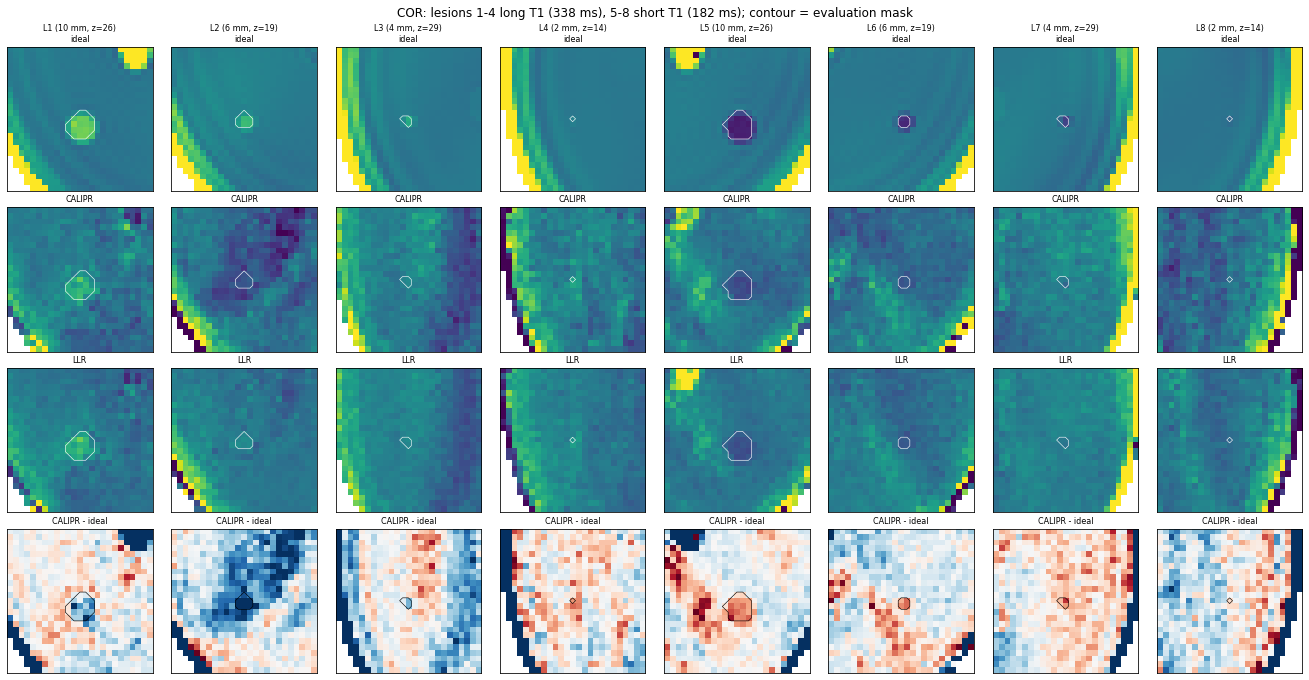

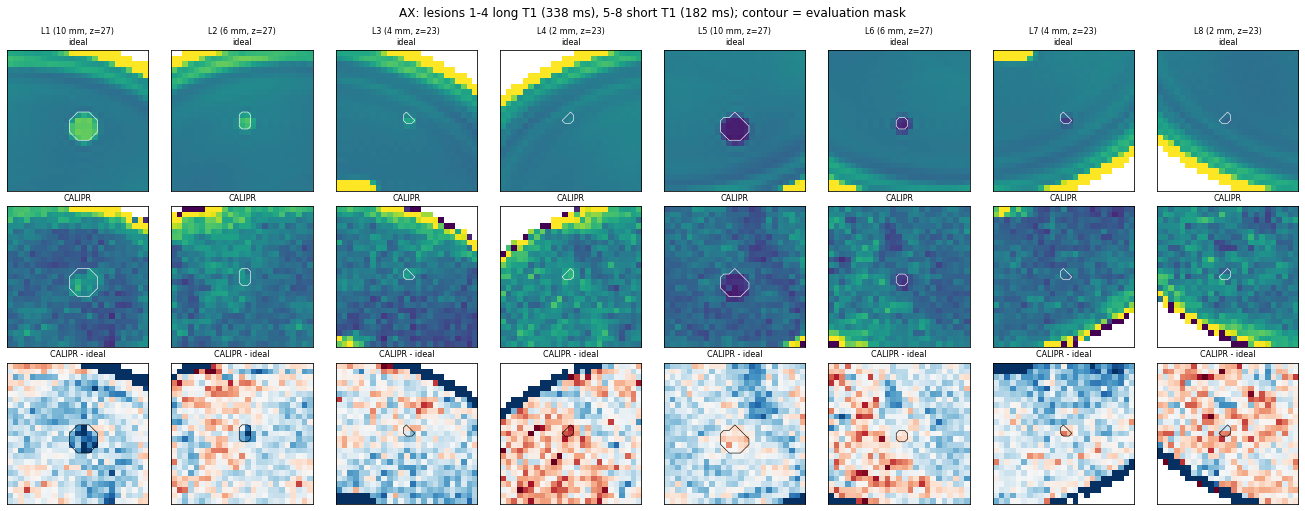

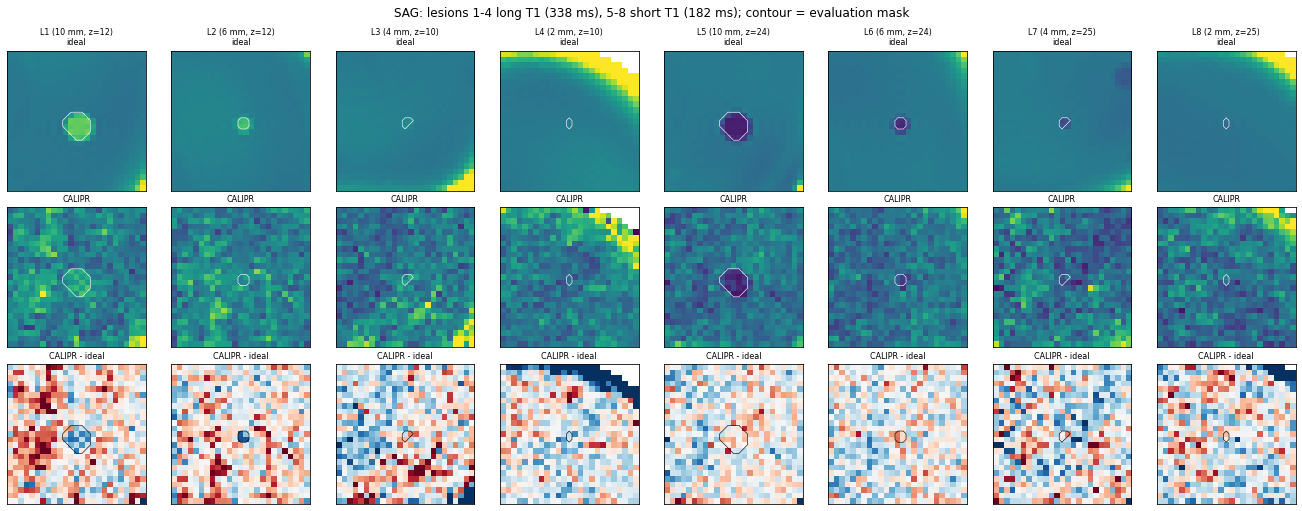

In [15]:
for p in PLANES:
    asp = aspect(p); fr_all = truth[p]['lesion_frac_by_id']; h = 12
    cols = [('ideal', lambda v: v, truth[p]['T1_ideal_ms'], 'viridis', 150, 420),
            ('CALIPR', None, 1000 * T1[p], 'viridis', 150, 420)]
    if llr.get(p) is not None:
        cols.append(('LLR', None, 1000 * llr[p]['T1_s'], 'viridis', 150, 420))
    cols.append(('CALIPR - ideal', None, 1000 * T1[p] - truth[p]['T1_ideal_ms'], 'RdBu_r', -80, 80))
    fig, axes = plt.subplots(len(cols), len(fr_all), figsize=(2.3 * len(fr_all), 2.4 * len(cols)), squeeze=False)
    for i, fr in enumerate(fr_all):
        x0, y0, z0 = np.unravel_index(np.argmax(fr), fr.shape)
        sl = (slice(max(x0 - h, 0), x0 + h + 1), slice(max(y0 - h, 0), y0 + h + 1), z0)
        for r, (name, _, vol, cm, lo, hi) in enumerate(cols):
            a = axes[r, i]
            a.imshow(vol[sl], cmap=cm, vmin=lo, vmax=hi, aspect=asp)
            a.contour(fr[sl] >= 0.5 * fr.max(), [0.5], colors='w' if cm == 'viridis' else 'k', linewidths=0.6)
            a.set_title(f'L{i + 1} ({LESIONS[i][2]} mm, z={z0})\n{name}' if r == 0 else name, fontsize=8)
            a.set_xticks([]); a.set_yticks([])
    plt.suptitle(f'{p}: lesions 1-4 long T1 (338 ms), 5-8 short T1 (182 ms); contour = evaluation mask')
    plt.tight_layout(); plt.show()

**Where the error sits.** T1 − ideal on several slices through the volume, and the median
error in brain (GM + WM + lesions) per slice, for CALIPR and (if available) LLR. A spatially
structured error that follows the undersampling (streaks, broad bands) is aliasing left by
too little regularisation; noise-like texture is noise.

COR CALIPR median T1 − ideal in brain per slice (ms):   .   .   .   .   .   . -40  -1 -12 -10  -9 -11  -7 -10  -8  -5  -2  -4  -4 -10  -6  -9  -4  -9  -2  -3  -3  -3  -2  -4  -3  -4  -3  -5  -1  -1 +15  -1 -28   .   .   .   .   .
COR LLR    median T1 − ideal in brain per slice (ms):   .   .   .   .   .   . -48 -15  -9  -8  -6  -3  -2  -2  -1  +0  +0  -1  -2  -3  +1  -3  -3  -8  -2  -1  -1  +0  +1  +1  +1  +1  +1  +1  +2  +4  +5  -9 -39   .   .   .   .   .


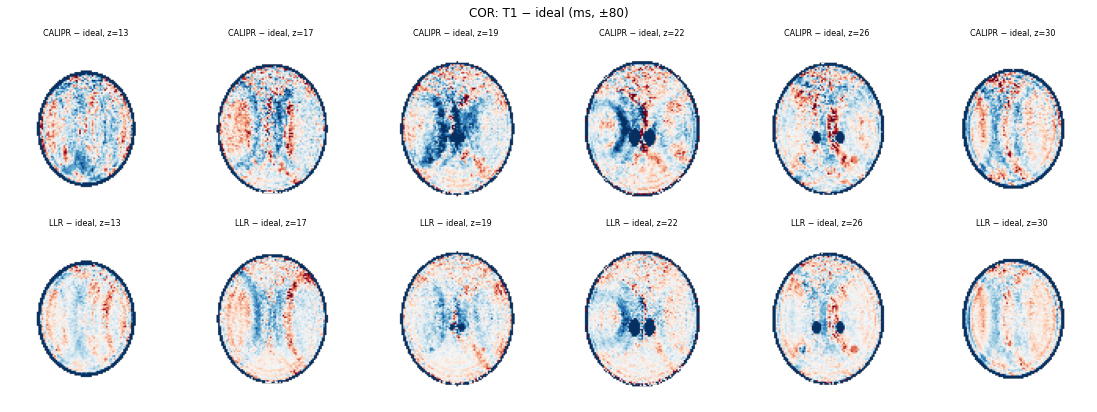

AX CALIPR median T1 − ideal in brain per slice (ms):   .   .   .   .   .   . -80 -55 -63 -48 -44 -47 -34 -28 -17 -14 -16 -15  -7  -5  -7  -9  -3  -4  -4  -6  -7  -6  -1  -4  +1  +5 +18 +15 +17   .   .   .   .   .


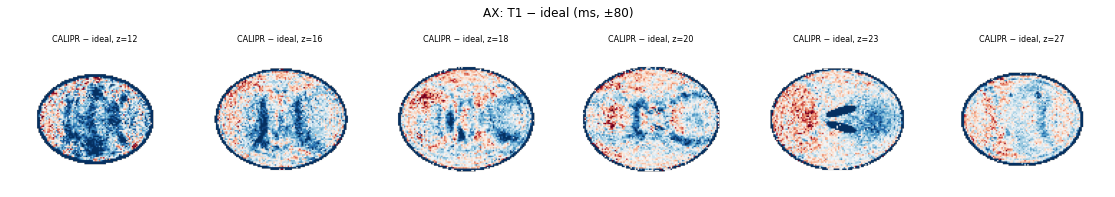

SAG CALIPR median T1 − ideal in brain per slice (ms):   .   .   .   .   .   . -44 -15  -4  -7  -8  -9  -3  -3  -4  -3  -4  -4  -8  -7  -7  -7  -7  -6  -5  -8  -1  -4  +0 -14 -47   .   .   .   .   .


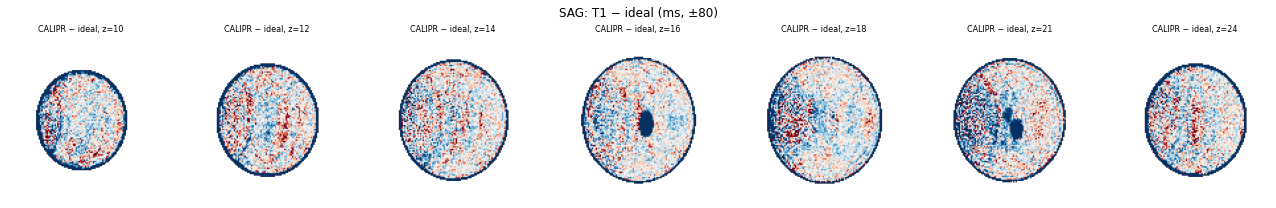

In [16]:
for p in PLANES:
    asp = aspect(p); brain = truth[p]['label'] >= 4
    nz = T1[p].shape[2]
    zs = sorted({int(round(f * (nz - 1))) for f in (0.3, 0.4, 0.45, 0.5, 0.6, 0.7)} | {lesion_slice(p)})
    maps_ = [('CALIPR', 1000 * T1[p])] + ([('LLR', 1000 * llr[p]['T1_s'])] if llr.get(p) is not None else [])
    fig, axes = plt.subplots(len(maps_), len(zs), figsize=(2.6 * len(zs), 2.9 * len(maps_)), squeeze=False)
    for r, (name, v) in enumerate(maps_):
        err = v - truth[p]['T1_ideal_ms']
        for j, z in enumerate(zs):
            axes[r, j].imshow(err[:, :, z], cmap='RdBu_r', vmin=-80, vmax=80, aspect=asp)
            axes[r, j].set_title(f'{name} − ideal, z={z}', fontsize=8); axes[r, j].axis('off')
        med = [np.nanmedian(err[:, :, z][brain[:, :, z]]) if brain[:, :, z].sum() > 50 else np.nan for z in range(nz)]
        print(f'{p} {name:6s} median T1 − ideal in brain per slice (ms): '
              + ' '.join('  .' if np.isnan(m) else f'{m:+3.0f}' for m in med))
    plt.suptitle(f'{p}: T1 − ideal (ms, ±80)'); plt.tight_layout(); plt.show()

### 10b. Phase-handling ablation (coronal, design check only)

Same reconstruction, same untuned parameters, but **without** per-TI demodulation
(`PHASE_MODE = 'none'`). This is not tuning: it only tests whether the design decision in
section 6 matters at the phantom's (and the real data's) ~5° offsets. Runs on COR only.

In [17]:
ablation = None
if RUN_PHASE_ABLATION and 'COR' in PLANES and PHASE_MODE == 'global_demod':
    p = 'COR'
    tag0 = CAL_TAG.replace('global_demod', 'none')
    img0 = {}
    for e in ECHO_GROUPS:
        _, img0[e], dt, state = calipr_recon(p, e, np.zeros(len(TI_s[p])), tag=tag0)
        runtime[p, e, 'ablation recon (not in total)'] = dt
        print(f'no-demod echo {e}: {dt:.0f} s [{state}]')
    S0 = np.mean([np.real(pu.combine_maps(img0[e])) for e in ECHO_GROUPS], axis=0)
    t10, _, _ = pu.fit_t1_grid(S0, TI_s[p], TR_s[p], truth[p]['label'] >= 3)
    ablation = pu.evaluate_t1(t10, truth[p])
    print(f"\n{'region':18s} {'ideal':>7s} {'demod':>7s} {'vs ideal':>9s} {'no demod':>9s} {'vs ideal':>9s}")
    for r, q in zip(rows[p], ablation):
        print(f"{r['region']:18s} {r.get('ideal_ms', np.nan):7.1f} {r['est_ms']:7.1f} "
              f"{r.get('bias_vs_ideal_pct', np.nan):+8.1f}% {q['est_ms']:9.1f} {q.get('bias_vs_ideal_pct', np.nan):+8.1f}%")
else:
    print('ablation skipped')

no-demod echo 0: 56 s [cached]
no-demod echo 1: 56 s [cached]



region               ideal   demod  vs ideal  no demod  vs ideal
WM                   259.8   254.7     -2.0%     255.0     -1.8%
GM                   308.8   302.5     -2.0%     303.2     -1.8%
CSF                 3862.6   223.5    -94.2%     227.1    -94.1%
lesion 1 (10 mm)     313.7   304.3     -3.0%     306.2     -2.4%
lesion 2 (6 mm)      304.2   229.5    -24.6%     227.4    -25.2%
lesion 3 (4 mm)      293.1   276.2     -5.7%     277.0     -5.5%
lesion 4 (2 mm)      268.3   303.8    +13.2%     302.1    +12.6%
lesion 5 (10 mm)     203.9   227.8    +11.7%     227.3    +11.4%
lesion 6 (6 mm)      211.5   230.0     +8.7%     229.5     +8.5%
lesion 7 (4 mm)      225.1   257.7    +14.4%     259.3    +15.2%
lesion 8 (2 mm)      238.9   253.9     +6.3%     252.5     +5.7%


## 11. Runtime

In [18]:
import platform
print(f'{platform.machine()}, {os.cpu_count()} cores; BART multithreaded (OpenMP). '
      'Times are wall-clock at first computation (cached values are the stored times).')
for p in PLANES:
    tot = 0.0
    for (pp, e, step), dt in runtime.items():
        if pp != p:
            continue
        print(f'{p}  echo {e if e is not None else "-"}  {step:32s} {dt:7.0f} s')
        if 'not in total' not in step:
            tot += dt
    print(f'{p}  total (coil maps + phase estimate + recon + fit, both echo groups): {tot:.0f} s = {tot / 60:.1f} min\n')

arm64, 10 cores; BART multithreaded (OpenMP). Times are wall-clock at first computation (cached values are the stored times).
COR  echo 0  coil maps                             84 s
COR  echo 1  coil maps                             82 s
COR  echo 0  phase estimate                        23 s
COR  echo 1  phase estimate                        14 s
COR  echo 0  subspace recon                        63 s
COR  echo 1  subspace recon                        59 s
COR  echo -  combine + fit                          2 s
COR  echo 0  ablation recon (not in total)         56 s
COR  echo 1  ablation recon (not in total)         56 s
COR  total (coil maps + phase estimate + recon + fit, both echo groups): 328 s = 5.5 min

AX  echo 0  coil maps                             85 s
AX  echo 1  coil maps                             77 s
AX  echo 0  phase estimate                        37 s
AX  echo 1  phase estimate                        37 s
AX  echo 0  subspace recon                       137 s
AX  e

## 12. Report (V1, 2026-09-29) — synthetic phantom only, untuned

**What was built.** A CALIPR-style subspace reconstruction on the shared pipeline:
dictionary IR basis (K = 3, SVD of 1000 unit-norm curves, T1 100-4000 ms, TIs/TRs from the
scan info) → shared-TI ENLIVE maps (2 map sets, `pu.shared_selfcal`) → per-TI global phase
estimated from a quick per-TI SENSE and demodulated in k-space → `pics -e -S -R W:7:0:0.005
-i 80 -U` with `t=, (p=), B=` as wrapper kwargs → `fmac -s 64` expansion → `combine_maps` →
echo-group average → `fit_t1_grid` → `evaluate_t1`. Basis layout `(1,1,1,1,1,TI,K)` verified
(toy problem + shape assertions; a transposed basis makes `pics` assert). Validated end to end
on COR; AX and SAG also run (AX exercises the zero-weight pattern with `-B`).

**Validation, coronal plane** (T1 in ms; bias vs ideal = reconstruction's own error; LLR =
`synth/run_llr_reference.py`, reproduced the brief's table to 0.1 ms, context only):

| region | true | ideal | CALIPR | vs ideal | LLR | vs ideal |
|---|---|---|---|---|---|---|
| WM | 259.8 | 259.8 | 254.7 ± 29.0 | −2.0 % | 258.6 ± 20.2 | −0.4 % |
| GM | 309.2 | 308.8 | 302.5 ± 37.3 | −2.0 % | 307.1 ± 30.9 | −0.5 % |
| CSF | 3543 | 3863 | 224 | −94 % (PSIR polarity) | 190 | −95 % |
| lesion 10 mm, long | 338 | 313.7 | 304.3 | −3.0 % | 293.5 | −6.4 % |
| lesion 6 mm, long | 338 | 304.2 | 229.5 | **−24.6 %** | 278.6 | −8.4 % |
| lesion 4 mm, long | 338 | 293.1 | 276.2 | −5.7 % | 275.6 | −5.9 % |
| lesion 2 mm, long (1 vox) | 338 | 268.3 | 303.8 | +13.2 % | 289.1 | +7.7 % |
| lesion 10 mm, short | 182 | 203.9 | 227.8 | +11.7 % | 230.2 | +12.9 % |
| lesion 6 mm, short | 182 | 211.5 | 230.0 | +8.7 % | 231.3 | +9.4 % |
| lesion 4 mm, short | 182 | 225.1 | 257.7 | +14.4 % | 259.8 | +15.4 % |
| lesion 2 mm, short (1 vox) | 182 | 238.9 | 253.9 | +6.3 % | 243.6 | +2.0 % |

AX / SAG (CALIPR only, no LLR run): WM −5.4 % / −1.6 %, GM −1.2 % / −3.3 %; lesions 10 mm
long −12.7 % / −8.0 %, short +1.1 % / −0.4 % (tables in section 9).

**Reading of the result (untuned!).** At these starting values CALIPR is **not better
than LLR**: WM/GM carry a −2 % bias and ~40 % higher SD, and the error maps (section 10)
show aliasing-shaped, spatially structured T1 underestimation with the same pattern as LLR
but stronger (median brain error per slice −2 to −12 ms vs 0 to −3 ms for LLR). The 6 mm
long-T1 lesion (−24.6 %) is not a lesion effect: it sits in such a band of low T1 (slices
16-22, see the lesion zoom) where the short-TI signal is too small in magnitude. The
lesion-contrast loss (long-T1 lesions pulled down, short-T1 lesions pulled up) is similar to
LLR's, so it looks mainly resolution/regularisation-driven rather than method-specific. The
$c_3$ coefficient images are essentially noise at lambda = 0.005, i.e. the wavelet penalty is
weak relative to the data scaling that `-S`/pics applies; this is the first thing to tune.
AX shows a strong through-slice (S/I) gradient in the error (−80 ms at the edge slices);
without an AX LLR run it is unknown whether that is CALIPR-specific.

**Design decisions and open choices**

* *Phase handling*: per-TI **global** phase, estimated by a magnitude-weighted, sign-free
  (squared) correlation of per-TI SENSE images with TI800, removed from k-space (equivalent
  to a complex basis). Estimates agree with the phantom's truth to ≤ 0.2° except the near-null
  TI150 (COR: 6.4° vs 9.6°; SAG 7.2° vs 6.0°). The ablation shows **no material effect** of
  demodulation at 5° SD (lesion/tissue biases change by ≤ 1.3 percentage points, mixed
  sign), so phase is not the dominant error at present. Not implemented: data-driven complex
  basis, joint/iterative phase estimation, spatially varying per-TI phase, real-valued
  coefficients (`pics -c`, which could halve the unknowns and is where a 4-TI subspace may gain
  most).
* *Map sets*: 2 soft-SENSE sets, each with its own K coefficients (2K complex unknowns per
  voxel), combined after expansion with `combine_maps` exactly as LLR. Map set 1's
  coefficients are mostly noise/aliasing here; 1 map set would halve the unknowns but has the
  band artefact on real data. Untested on the phantom which is better for CALIPR.
* *Basis*: dictionary SVD, unit-norm curves (equal weight per T1). K = 3 as briefed (worst-case
  curve error 4.3 %, T1 bias from projection alone ≤ 0.2 % for 182-380 ms). **K = 2** gives
  ≤ 1.3 % projection bias in parenchyma (−11 % for CSF), halving the unknowns — a real
  candidate for tuning. Not implemented: data-driven basis (SVD of a preliminary recon, as in
  the CALIPR T2 code), per-coefficient scaling.
* *Regulariser*: W:7 (3D, including the 5 mm through-plane dim), no joint dims, one lambda for
  all coefficients (as in the CALIPR reference). Iterations 80 to match LLR.

**Runtime** (wall clock; the 10-core laptop was shared with other BART jobs during all runs,
so absolute numbers are inflated and not a fair comparison): COR 5.5 min total (coil maps
2 × ~83 s, phase estimate 2 × ~20 s, subspace recon 2 × ~60 s, fit 2 s); AX 8.5 min;
SAG 8.0 min. LLR reference on COR in the same session: 33.6 min (brief: ~16 min unloaded),
i.e. CALIPR's reconstruction step was roughly an order of magnitude faster per echo.

**Known limitations.** Synthetic data only; untuned; CSF fails in PSIR (shared limitation);
single-voxel 2 mm lesions are not meaningful as averages; the phase estimate uses a
separate quick SENSE (noisy at the null TI); global-phase model only; no oracle-coil-map
run yet; runtimes measured under load.

**Parameters to tune (with the researcher):** `CAL_LAMBDA` (first; c3 currently
unregularised in effect), `CAL_ITER`, `BASIS_K` (2 vs 3), dictionary range/normalisation,
per-coefficient weighting or joint sparsity (`W:7:64:λ`), wavelet dims (7 vs in-plane 3) and
type, `SENS_NMAPS` (1 vs 2), `PHASE_MODE`/`PHASE_EST_CMD`, real-valued coefficient option
(`-c`), solver (FISTA vs ADMM) and `-S`/scaling interplay.